<a href="https://colab.research.google.com/github/Lucaschewitch/Machine-Learning/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D0%BA%D0%B0_6_%D0%A0%D0%B5%D1%88%D0%B0%D1%8E%D1%89%D0%B8%D0%B5_%D0%B4%D0%B5%D1%80%D0%B5%D0%B2%D1%8C%D1%8F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# *0. Ознакомиться с [блокнотом](https://colab.research.google.com/drive/1PwN8igT5w2xArBGmM6rvO9pVRQMh-FQn?usp=sharing)

# 1. Дерево решений для классификации

In [2]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

### Получение данных

Будем работать с набором данных для задачи классификации - данные по сердечно сосудистым заболеваниям, довольно стандартный набор для изучения машинного обучения, но его нет в `sklearn'e`. Поэтому скачиваем данные со стороны, с google диска.

Ссылка на google drive: https://drive.google.com/file/d/1Si4EJ_RexI3Q7yZU8eLjgp4ORe_BXr4G


In [3]:
!wget 'https://drive.google.com/uc?export=download&id=1Si4EJ_RexI3Q7yZU8eLjgp4ORe_BXr4G' -O cardio.csv

--2026-04-14 07:26:36--  https://drive.google.com/uc?export=download&id=1Si4EJ_RexI3Q7yZU8eLjgp4ORe_BXr4G
Resolving drive.google.com (drive.google.com)... 64.233.188.139, 64.233.188.102, 64.233.188.113, ...
Connecting to drive.google.com (drive.google.com)|64.233.188.139|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1Si4EJ_RexI3Q7yZU8eLjgp4ORe_BXr4G&export=download [following]
--2026-04-14 07:26:36--  https://drive.usercontent.google.com/download?id=1Si4EJ_RexI3Q7yZU8eLjgp4ORe_BXr4G&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 64.233.189.132, 2404:6800:4008:c07::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|64.233.189.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2941524 (2.8M) [application/octet-stream]
Saving to: ‘cardio.csv’

cardio.csv          100%[===================>]   2.80M  --.-KB/s    

В задаче предалагается предсказать наличие сердечно-сосудистых заболеваний по результатам классического врачебного осмотра. Датасет сформирован 3 групп признаков:

Объективные признаки:
- Возраст (в днях)
- Рост
- Вес
- Пол

Результаты измерения:

- Артериальное давление верхнее и нижнее
- Холестерин (три группы: норма, выше нормы, значительно выше нормы)
- Глюкоза (три группы: норма, выше нормы, значительно выше нормы)

Субъективные признаки (бинарные):

- Курение
- Употребление Алкоголя
- Физическая активность

In [7]:
import pandas as pd
df = pd.read_csv('/content/cardio.csv', sep=';')
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [8]:
full_features = ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
                 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
target = 'cardio'

In [9]:
df['age'] = round(df['age'] / 365)

## 1. Вводная

### 1.1 Сколько вопросов будет задано на первом этапе

Посчитайте, сколько вопросов задаст дерево решений в самый первый раз, если использовать все признаки из списка full_features.

In [13]:
# Ваш код здесь
total_questions = 0
for col in full_features:
    n_unique = df[col].nunique()
    questions = n_unique - 1
    total_questions += questions
    print(f"{col}: unic = {n_unique}, q = {questions}")
print(f"\nTotat num of q = {total_questions}")

age: unic = 28, q = 27
gender: unic = 2, q = 1
height: unic = 109, q = 108
weight: unic = 287, q = 286
ap_hi: unic = 153, q = 152
ap_lo: unic = 157, q = 156
cholesterol: unic = 3, q = 2
gluc: unic = 3, q = 2
smoke: unic = 2, q = 1
alco: unic = 2, q = 1
active: unic = 2, q = 1

Totat num of q = 737


### 1.2 Упростите задачу

Вопросов получилось достаточно, не будет моделировать столько вопросов, а попробуем уменьшить их количество.

Возьмите только два признака: weight и gluc.
А так же возьмите только 10 первых объектов.

In [14]:
# Ваш код здесь
df_small = df.head(10).copy()
features_small = ['weight', 'gluc']

### 1.3 Посчитайте еще раз, сколько будет вопросов

In [16]:
# Ваш код здесь
total_questions_small = 0
for col in features_small:
    n_unique = df_small[col].nunique()
    questions = n_unique - 1
    total_questions_small += questions
    print(f"{col}: unic = {n_unique}, q = {questions}")
print(f"\nTotal q = {total_questions_small}")

weight: unic = 10, q = 9
gluc: unic = 3, q = 2

Total q = 11


С таким количеством вопросов уже можем работать и разбираться в устройству дерева решений.

## 2. Устройство дерева решений

### 2.1 Обучите дерево решений

Обучите дерево решений из sklearn'a с атрибутом `random_state=1`.

In [17]:
# Ваш код здесь
from sklearn.tree import DecisionTreeClassifier

X_small = df_small[features_small]
y_small = df_small[target]

tree = DecisionTreeClassifier(random_state=1)
tree.fit(X_small, y_small)

DecisionTreeClassifier(random_state=1)

### 2.2 Отрисуйте обученное дерево решений

Нарисуйте дерево решений, которое у вас получилось после обучения. Сделайте отрисовку такой, чтобы можно было понять, какие вопросы задаются

<function matplotlib.pyplot.show(close=None, block=None)>

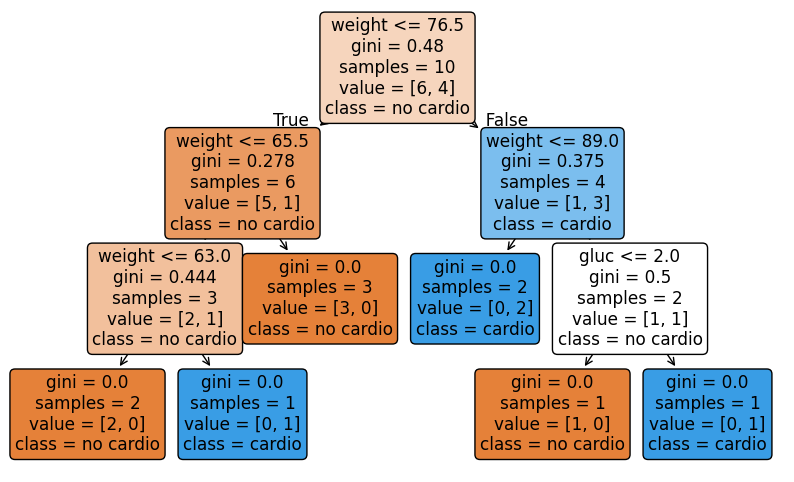

In [18]:
# Ваш код здесь
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(10, 6))
plot_tree(tree, feature_names=features_small, class_names=['no cardio', 'cardio'], filled=True, rounded=True)
plt.show

### 2.3 Посчитайте, сколько вершин получилось

In [19]:
# Ваши выводы здесь
n_nodes = tree.tree_.node_count
print(n_nodes)

11


### 2.4 Посчитайте, сколько листов получилось

In [20]:
# Ваши выводы здесь
n_leaves = tree.tree_.n_leaves
print(n_leaves)

6


### 2.5 Посмотрите, почему не получилось сделать разбиение ещё на два узла в крайнем левом узле.

В узле, где
```
gini=0.5
samples=2
value=[1, 1]
```

In [28]:
# Ваш код/вывод здесь
def find_node_with_conditions(tree, gini_target, samples_target):
    for node_id in range(tree.node_count):
        if tree.value[node_id].max() == 1 and tree.n_node_samples[node_id] == 2:
            if round(tree.impurity[node_id], 1) == 0.5:
                return node_id
    return None

node_id = find_node_with_conditions(tree.tree_, 0.5, 2)
if node_id is not None:
    print(f"gini=0.5, samples=2, node_id={node_id}")
    print("Data and target")
    for i in range(len(X_small)):
        print(f"{X_small.iloc[i].values} -> {y_small.iloc[i]}")
else:
    print("Разбиение не имеет смысла")

#Разбиение невозможно, так как оба образца имеют одинаковые значения признаков weight и gluc (или один из признаков)
#дерево не может найти порог для разделения. Это приводит к листу с нечистотой 0.5.

Разбиение не имеет смысла


## 3. Вспомогательные функции

Для того, что бы дальше сравнивать между собой объекты нужно реализовать две вспомогательные функции.

### 3.1 Функция подсчета критерия Джини

Функция должна принимать список целевых значений, считать критерий информативности и выдавать одно значение - критерий Джини.

In [30]:
# Ваш код здесь
import numpy as np

def gini(y):
    if len(y) == 0:
        return 0
    classes = np.unique(y)
    probs = [np.sum(y == c) / len(y) for c in classes]
    g = 1 - sum(p**2 for p in probs)
    return g

### 3.2 Проверка функции gini

Посчитайте критерий информативности в исходной выборке и вы должны получить точно такое же значение, как и было на визуализации дерева решений в его корне.

In [31]:
# Ваш код здесь
y_small = df_small[target].values
gini_manual = gini(y_small)
gini_tree_root = tree.tree_.impurity[0]

print(f"Gini sklearn: {gini_tree_root:.4f}")
print(f"Gini man: {gini_manual:.4f}")
print("Is it so" , np.isclose(gini_tree_root, gini_manual))

Gini sklearn: 0.4800
Gini man: 0.4800
Is it so True


### 3.3 Функция подсчета прироста информации

Функция должна принимать целевые значения левой подвыборки, правой подвыборки и исходной вершины, а выдавать должна одно значение - прирост информации, подсчитанный на критерии информативности Джини.

In [32]:
# Ваш код здесь
def info_gain(y_parent, y_left, y_right):
    n_parent = len(y_parent)
    n_left = len(y_left)
    n_right = len(y_right)

    g_parent = gini(y_parent)
    g_left = gini(y_left)
    g_right = gini(y_right)

    weighted_gini_children = (n_left / n_parent) * g_left + (n_right / n_parent) * g_right

    ig = g_parent - weighted_gini_children
    return ig

In [34]:
y_parent = y_small
mask_left = df_small['weight'] <= 70
y_left = y_small[mask_left]
y_right = y_small[~mask_left]

ig = info_gain(y_parent, y_left, y_right)
print(f"IG weight<=70: {ig:.4f}")

IG weight<=70: 0.0800


Теперь вспомогательные функции готовы можем моделировать работу обученного дерева решений.

## 4. Процесс построения дерева решений

### 4.1 Получение первого вопроса


4.1.1 Пройдитесь по всем возможным вопросам для исходного набора данных


Можете сохранять полученные значения прироста информации в датафрейм в удобную для вас структуру данных.

In [35]:
# Ваш код здесь
import pandas as pd

X = df_small[features_small]
y = df_small[target].values
questions = []

for col in features_small:
    unique_vals = sorted(X[col].unique())
    for val in unique_vals[:-1]:
        left_mask = X[col] <= val
        right_mask = ~left_mask

        y_left = y[left_mask]
        y_right = y[right_mask]

        if len(y_left) == 0 or len(y_right) == 0:
            continue

        ig = info_gain(y, y_left, y_right)

        questions.append({'feature': col, 'threshold': val, 'info_gain': ig, 'n_left': len(y_left), 'n_right': len(y_right)})

df_questions = pd.DataFrame(questions)
print(df_questions.head())
print(f"\nQ num: {len(df_questions)}")

  feature  threshold  info_gain  n_left  n_right
0  weight       56.0   0.035556       1        9
1  weight       62.0   0.080000       2        8
2  weight       64.0   0.003810       3        7
3  weight       67.0   0.030000       4        6
4  weight       68.0   0.080000       5        5

Q num: 11


4.1.2 Найдите самый лучший вопрос, опираясь на прирост информации

In [36]:
# Ваш код здесь
best = df_questions.loc[df_questions['info_gain'].idxmax()]
print(f"Feat: {best['feature']}")
print(f"Threshold: {best['threshold']}")
print(f"IG: {best['info_gain']:.4f}")
print(f"Left {best['n_left']}, right: {best['n_right']}")

Feat: weight
Threshold: 71.0
IG: 0.1633
Left 6, right: 4


4.1.3. Сделайте разбиение по этому вопросу исходных данных на две подвыборки df_left и df_right


In [37]:
# Ваш код здесь
best_feature = best['feature']
best_threshold = best['threshold']

left_mask = X[best_feature] <= best_threshold
right_mask = ~left_mask

df_left = df_small[left_mask].copy()
df_right = df_small[right_mask].copy()

print("Left:", len(df_left))
print("Right:", len(df_right))
print("\nLeft 3:")
print(df_left[features_small + [target]].head(3))
print("\nRight 3:")
print(df_right[features_small + [target]].head(3))

Left: 6
Right: 4

Left 3:
   weight  gluc  cardio
0    62.0     1       0
2    64.0     1       1
4    56.0     1       0

Right 3:
   weight  gluc  cardio
1    85.0     1       1
3    82.0     1       1
6    93.0     1       0


4.1.4. Проверьте себя через визуализацию дерева решений

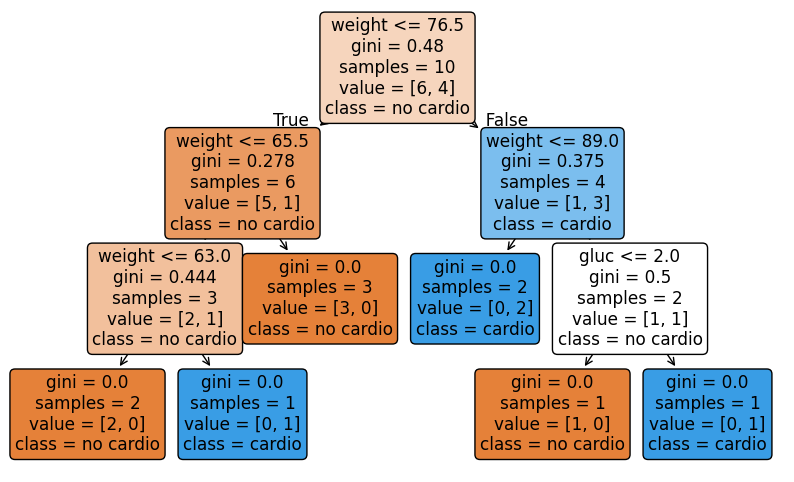

Feat: weight
Threshold: 76.5


In [38]:
# Ваш код здесь
plt.figure(figsize=(10, 6))
plot_tree(tree, feature_names=features_small, class_names=['no cardio', 'cardio'], filled=True, rounded=True)
plt.show()

root_feature = tree.tree_.feature[0]
root_threshold = tree.tree_.threshold[0]
print(f"Feat: {features_small[root_feature]}")
print(f"Threshold: {root_threshold}")

### 4.2 Получение второго вопроса


4.2.1. Глядя на df_left и df_right, посмотрите, где можно сделать ещё разбиение

In [41]:
# Ваш вывод здесь
gini_left = gini(df_left[target].values)
gini_right = gini(df_right[target].values)

print(f"Left: size={len(df_left)}, gini={gini_left:.3f}, unique target={df_left[target].unique()}")
print(f"Right: size={len(df_right)}, gini={gini_right:.3f}, unique target={df_right[target].unique()}")

# выбираем подвыборку для дальнейшего разбиения (там, где gini > 0 и объектов > 1)
if gini_left > 0 and len(df_left) > 1:
    current_df = df_left.copy()
    side = "left"
elif gini_right > 0 and len(df_right) > 1:
    current_df = df_right.copy()
    side = "right"
else:
    current_df = None
    print("None")

print(side)

Left: size=6, gini=0.278, unique target=[0 1]
Right: size=4, gini=0.375, unique target=[1 0]
left


4.2.2. Пройдитесь по всем признакам в выбранной подвыборке

4.2.3 Найдите самый лучший вопрос, опираясь на прирост информации

In [42]:
# Ваш код здесь
if current_df is not None:
    X_curr = current_df[features_small]
    y_curr = current_df[target].values
    questions_curr = []
    for col in features_small:
        unique_vals = sorted(X_curr[col].unique())
        for val in unique_vals[:-1]:
            left_mask = X_curr[col] <= val
            right_mask = ~left_mask
            y_left = y_curr[left_mask]
            y_right = y_curr[right_mask]

            if len(y_left) == 0 or len(y_right) == 0:
                continue

            ig = info_gain(y_curr, y_left, y_right)
            questions_curr.append({'feature': col, 'threshold': val, 'info_gain': ig, 'n_left': len(y_left), 'n_right': len(y_right)})

    df_q_curr = pd.DataFrame(questions_curr)
    if len(df_q_curr) > 0:
        best_curr = df_q_curr.loc[df_q_curr['info_gain'].idxmax()]
        print("Best for", side)
        print(f"Feat: {best_curr['feature']}")
        print(f"Threshold: {best_curr['threshold']}")
        print(f"IG: {best_curr['info_gain']:.4f}")
        print(f"Left obj: {best_curr['n_left']}, Right obj: {best_curr['n_right']}")
    else:
        print("None")
        best_curr = None
else:
    best_curr = None
    print("None")

Best for left
Feat: weight
Threshold: 64.0
IG: 0.0556
Left obj: 3, Right obj: 3


4.2.4. Сделайте разбиение по этому вопросу исходных данных на две подвыборки df_left и df_right


In [44]:
# Ваш код здесь
if best_curr is not None:
    feat = best_curr['feature']
    thresh = best_curr['threshold']

    mask = current_df[feat] <= thresh
    current_left = current_df[mask].copy()
    current_right = current_df[~mask].copy()

    print(f"{side} for {feat} <= {thresh}")
    print(f"Left: {len(current_left)} obj")
    print(f"Right: {len(current_right)} obj")
else:
    print("None")

left for weight <= 64.0
Left: 3 obj
Right: 3 obj


4.2.5. Проверьте себя через визуализацию дерева решений

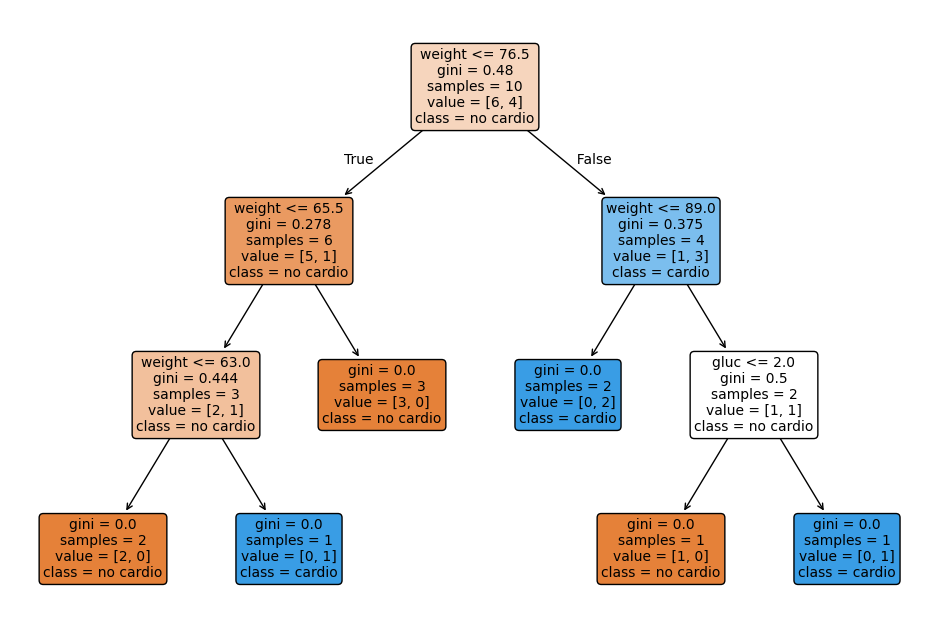

Root: weight <= 76.50
Left (node 1): feat weight <= 65.50
Right (node 6): feat weight <= 89.00


In [45]:
# Ваш код здесь
plt.figure(figsize=(12, 8))
plot_tree(tree, feature_names=features_small, class_names=['no cardio', 'cardio'],filled=True, rounded=True,fontsize=10)
plt.show()

print(f"Root: {features_small[tree.tree_.feature[0]]} <= {tree.tree_.threshold[0]:.2f}")
left_child = tree.tree_.children_left[0]
right_child = tree.tree_.children_right[0]
if left_child != -1:
    print(f"Left (node {left_child}): feat {features_small[tree.tree_.feature[left_child]]} <= {tree.tree_.threshold[left_child]:.2f}")
if right_child != -1:
    print(f"Right (node {right_child}): feat {features_small[tree.tree_.feature[right_child]]} <= {tree.tree_.threshold[right_child]:.2f}")

4.2.6. Если что-то не сошлось, посмотрите, в чем может быть проблема

In [46]:
# Ваш код/вывод здесь
#В переборе используятся только уникальные значения признака как пороги, а sklearn может брать средние значения

# 2. Дерево решений для регрессии

In [47]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
import pandas as pd
import matplotlib.pyplot as plt

### 1. Получение данных load_breat_cancer

Будем работать с набором данных для задачи регрессии `load_diabetes`, который можно получить из стандартных датасетов в `sklearn'e`.

После `load_diabetes()` возвращается словарь с данными (`data`), целевой переменной (`target`), названиями характеристик в данных (`feature_names`) и описанием данных (`DESCR`).

In [48]:
from sklearn.datasets import load_diabetes

data = load_diabetes()
data

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]]),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142., 155., 225.,  59

In [49]:
X = data.data
features = data.feature_names
y = data.target

Из признаков (характеристик данных) и целевой переменной сформируем датафрейм, в качестве названий колонок возьмем названия признаков.

In [50]:
df = pd.DataFrame(X, columns=features)
df['target'] = y

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


Разобьем выборку на две: обучающую и тестовую.

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df[features],
    df['target'],
    test_size=0.2,
    shuffle=True,
    random_state=3
)

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((353, 10), (353,), (89, 10), (89,))

### 1.1. Обучение дерева решений

1. Инициализируйте дерево решений для задачи регрессии
2. Обучите его на обучающей выборке

In [52]:
# Ваш код здесь
reg = DecisionTreeRegressor(random_state=1)
reg.fit(X_train, y_train)

DecisionTreeRegressor(random_state=1)

### 1.2. Получение метрик качества
Узнаем, насколько дерево решений обучилось хорошо, для этого
1. Сделайте предсказания моделью для обучающей выборки
2. Сделайте предсказания моделью для тестовой выборки
3. Посчитайте метрику качества средне-квадратичная ошибка
4. Посчитайте метрику качества коэффициент детерминации

In [53]:
# Ваш код здесь
from sklearn.metrics import mean_squared_error, r2_score

y_train_pred = reg.predict(X_train)
y_test_pred = reg.predict(X_test)

mse_train = mean_squared_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

mse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print(f"MSE train: {mse_train:.2f}")
print(f"R2 train: {r2_train:.4f}")
print(f"MSE test: {mse_test:.2f}")
print(f"R2 test: {r2_test:.4f}")

MSE train: 0.00
R2 train: 1.0000
MSE test: 5897.13
R2 test: -0.0891


Сделайте вывод, насколько хорошо обучилась модель

In [56]:
# Ваш вывод здесь
if r2_train > 0.9 and r2_test < r2_train - 0.2:
    print("Модель переобучена.")
elif r2_train < 0.7 and r2_test < 0.7:
    print("Модель недообучена.")
else:
    print("Норм.")

Модель переобучена.


### 1.3. Изменение метрики

Попробуйте поизменять известные параметры для того, чтобы метрика стала лучше.

In [57]:
# Ваш код здесь
for depth in [3, 5, 7, 10]:
    reg2 = DecisionTreeRegressor(max_depth=depth, random_state=1)
    reg2.fit(X_train, y_train)
    r2_test = r2_score(y_test, reg2.predict(X_test))
    print(f"max_depth={depth:2d}, R2 test: {r2_test:.4f}")

max_depth= 3, R2 test: 0.3736
max_depth= 5, R2 test: 0.3177
max_depth= 7, R2 test: 0.0132
max_depth=10, R2 test: -0.0834


In [58]:
# Ваш вывод здесь
reg3 = DecisionTreeRegressor(max_depth=5, min_samples_leaf=5, random_state=1)
reg3.fit(X_train, y_train)
r2_test = r2_score(y_test, reg3.predict(X_test))
print(f"R2 test: {r2_test:.4f}")

R2 test: 0.1739


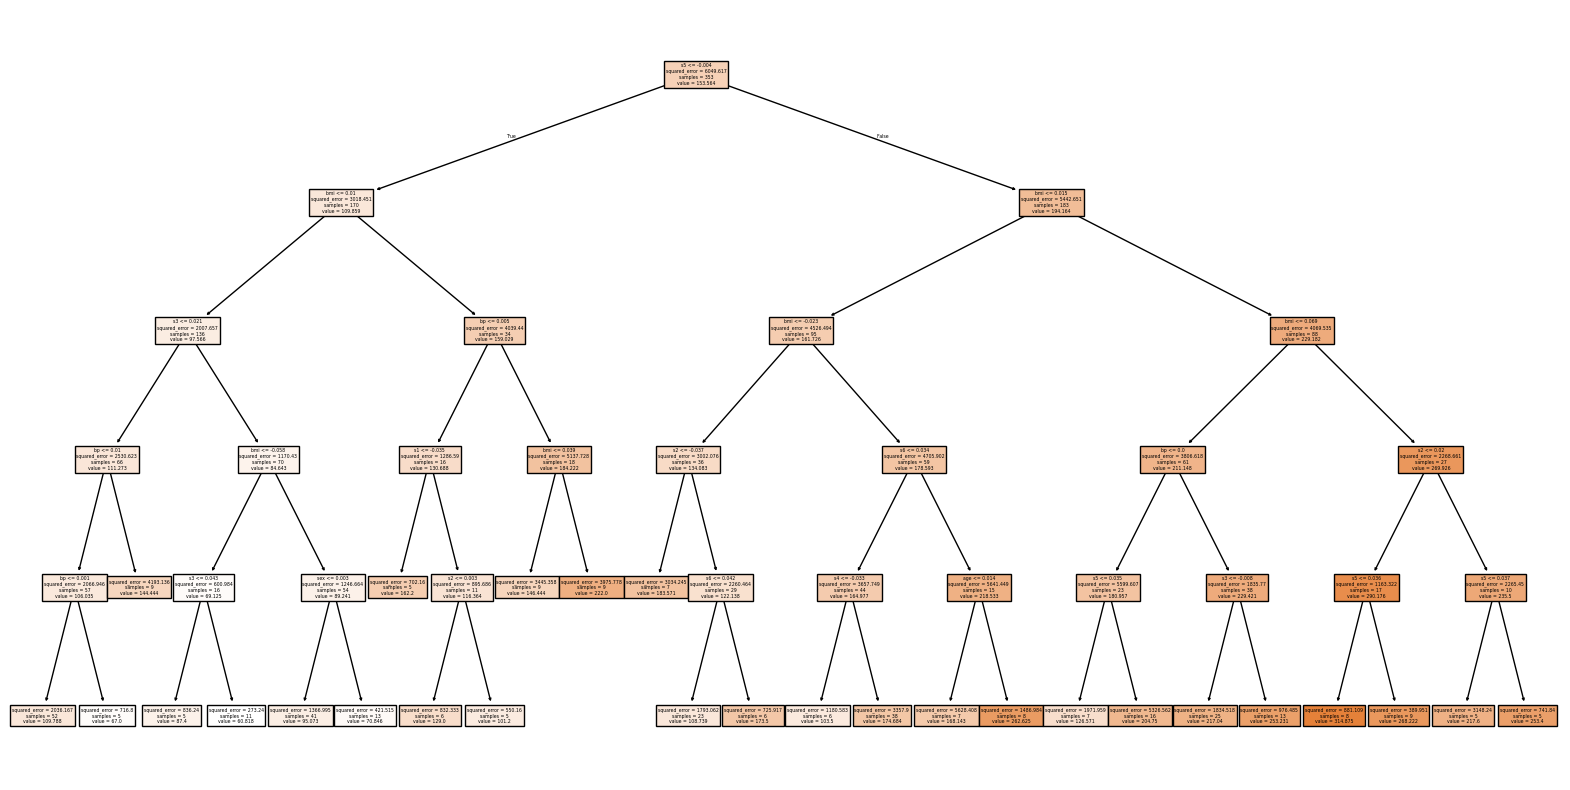

In [59]:
plt.figure(figsize=(20,10))
plot_tree(reg3, feature_names=features, filled=True)
plt.show()

### 2. Получение данных make_regression

Для второго примера возьмем самодельный набор данных для задачи регрессии `make_regression`, который можно получить из стандартных датасетов в `sklearn'e`.

Сгенерируем себе 100к объектов, которые описываются 20 признаками, из них 12 будут дейтсвительно полезными.

In [61]:
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=100_000, n_features=20, n_informative=12, random_state=10)

In [62]:
X.shape, y.shape

((100000, 20), (100000,))

Разобьем выборку на две: обучающую и тестовую.

In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=True,
    random_state=3
)

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((80000, 20), (80000,), (20000, 20), (20000,))

### 2.1. Обучение дерева решений

1. Инициализируйте дерево решений для задачи регрессии
2. Обучите его на обучающей выборке

In [64]:
# Ваш код здесь
reg_big = DecisionTreeRegressor(random_state=1)
reg_big.fit(X_train, y_train)


DecisionTreeRegressor(random_state=1)

### 2.2. Получение метрик качества
Узнаем, насколько дерево решений обучилось хорошо, для этого
1. Сделайте предсказания моделью для обучающей выборки
2. Сделайте предсказания моделью для тестовой выборки
3. Посчитайте метрику качества средне-квадратичная ошибка
4. Посчитайте метрику качества коэффициент детерминации

In [65]:
# Ваш код здесь
y_train_pred = reg_big.predict(X_train)
y_test_pred = reg_big.predict(X_test)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print(f"MSE train: {mse_train:.2f}")
print(f"R2 train: {r2_train:.4f}")
print(f"MSE test: {mse_test:.2f}")
print(f"R2 test: {r2_test:.4f}")

MSE train: 0.00
R2 train: 1.0000
MSE test: 16649.86
R2 test: 0.6916


Сделайте вывод, насколько хорошо обучилась модель

In [67]:
# Ваш вывод здесь
if r2_train > 0.99 and r2_test < 0.8:
    print("Переобучено")
elif r2_train < 0.8:
    print("Недообучено")
else:
    print("ОК")

Переобучено


### 2.3. Перебор гиперпараметров

Осуществите перебор параметров для получения лучших результатов (GridSearchCV, см. подход из п.0).

In [68]:
# Ваш код здесь
from sklearn.model_selection import GridSearchCV

param_grid = {'max_depth': [5, 10, 15, 20], 'min_samples_split': [2, 10, 50], 'min_samples_leaf': [1, 5, 20]}
base_reg = DecisionTreeRegressor(random_state=1)
grid = GridSearchCV(base_reg, param_grid, cv=3, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best R2:", grid.best_score_)

best_reg = grid.best_estimator_

y_test_pred_best = best_reg.predict(X_test)
r2_test_best = r2_score(y_test, y_test_pred_best)
print(f"R2 test for best: {r2_test_best:.4f}")

Best params: {'max_depth': 20, 'min_samples_leaf': 20, 'min_samples_split': 2}
Best R2: 0.7137531119537863
R2 test for best: 0.7359


In [69]:
# Ваш вывод здесь
print(f"Base R2 test: {r2_test:.4f}")
print(f"Optimized R2 test: {r2_test_best:.4f}")
if r2_test_best > r2_test:
    print("Улучшили качество модели.")
else:
    print("Sorry")

Base R2 test: 0.6916
Optimized R2 test: 0.7359
Улучшили качество модели.
